In [1]:
import importlib
import coupling_utils as cl
import element
import numpy as np

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [10]:
m_t = 173

Decay

In [ ]:
N = 10
X = torch.rand(N, 5, device=device, dtype=torch.float64)
(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
print(P.shape, P1.shape, P2.shape, P3.shape, jac_map.shape)


torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10])


In [ ]:
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [6]:
me_values = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=np.float64) * jac_map
print(me_values)

tensor([2.2198e+04, 1.0047e+05, 2.3257e+06, 5.8298e+04, 3.9113e+06, 7.3821e+06,
        2.9437e+05, 1.8931e+05, 3.9638e+05, 5.2380e+04, 6.7091e+02, 2.2283e+04,
        3.1972e+05, 1.4372e+05, 2.0780e+06, 1.4023e+06, 1.0396e+04, 2.2961e+05,
        5.4672e+07, 1.9118e+05, 7.8640e+04, 4.4394e+07, 3.4590e+05, 1.3285e+06,
        3.5162e+05, 6.4787e+06, 6.4624e+03, 9.0090e+05, 2.8801e+05, 9.1414e+04,
        1.2030e+05, 8.3774e+04, 2.3125e+06, 2.4451e+04, 1.1819e+05, 1.3685e+04,
        1.9594e+06, 5.7449e+05, 4.8728e+05, 3.1392e+04, 2.0717e+05, 1.7355e+05,
        1.6933e+04, 1.7987e+05, 1.4421e+05, 6.9132e+05, 9.5460e+05, 1.6553e+04,
        3.7167e+04, 1.1303e+05, 1.1026e+05, 4.2716e+05, 6.1296e+04, 1.2846e+08,
        3.1227e+05, 7.3285e+03, 7.3266e+05, 3.0068e+07, 1.8101e+07, 5.9889e+05,
        2.0238e+04, 2.1711e+04, 2.1968e+05, 4.0583e+04, 1.2039e+05, 3.1542e+04,
        4.9662e+04, 1.1549e+06, 2.3728e+04, 1.1146e+05, 3.3738e+07, 4.2253e+05,
        4.0942e+03, 3.5167e+04, 8.0312e+

Train flow

In [6]:
A_dims = [torch.tensor([1, 2, 3, 4]),
          torch.tensor([0, 2, 3, 4]),
          torch.tensor([0, 1, 3, 4]),
          torch.tensor([0, 1, 2, 3])]


B_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([2]),
          torch.tensor([3]),
          torch.tensor([4])]

In [7]:
final_loss, loss_values, flow = cl.train_loop_decay(
    D=5,
    layer_type=cl.pwl_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    N=1000,
    epochs=6000,
    lr=3e-5,
    device=device,
    dtype=np.float64,
    ticker=True
)

Normalisation scale: 22849042.615281988
Epoch: 0 | Loss: 8.33000127e-01
Mean value:  4461950.373878195
Std h : 20854056.289880298
me2 min/max: 0.001161819147328374 729.0275009842029
jac_dets min/max: 0.2292426942640111 3.9564401149928647
jac_dets abs mean: 1.0119477158272143
X min/max: 0.0 0.9987744068765471
X, jac_dets, me2, h_evals all finite? True True True True
Epoch: 20 | Loss: 8.49133303e-01
Mean value:  4473295.77261302
Std h : 21055033.885564066
me2 min/max: 0.0021157192120313385 735.679547255892
jac_dets min/max: 0.25328295733622025 4.212010198605569
jac_dets abs mean: 1.0072015073487217
X min/max: 0.0 0.9996316999743246
X, jac_dets, me2, h_evals all finite? True True True True
Epoch: 40 | Loss: 9.16110032e-01
Mean value:  4404798.817948343
Std h : 21869649.726296723
me2 min/max: 0.0007569145419982375 750.9569449425188
jac_dets min/max: 0.2289772714909035 4.136402855290992
jac_dets abs mean: 0.9950689089734652
X min/max: 0.0 0.9999364504151191
X, jac_dets, me2, h_evals all fin

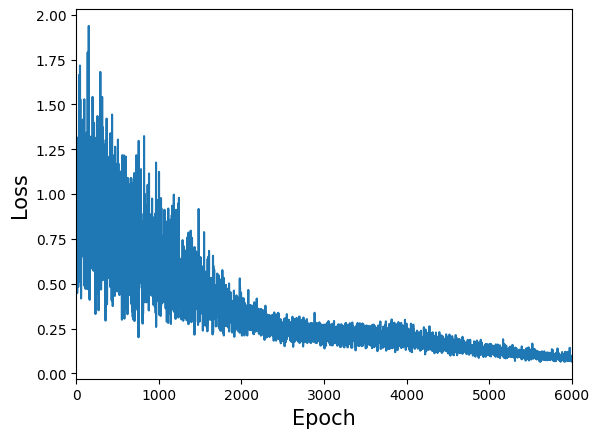

In [9]:
fig, ax = plt.subplots()

epochs_plot = torch.arange(len(loss_values))
ax.plot(epochs_plot, loss_values.cpu().numpy())

ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15)
ax.set_xlim(0, len(loss_values))

plt.show()

In [11]:
B = 500000
Y = torch.rand((B, 5), device='cpu', dtype=torch.float64)
flow = flow.to(device='cpu')

X, jac_dets = flow.inverse(Y)
X, jac_dets = X.detach(), jac_dets.detach()

(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)
prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)
weights = prefactor * me2_vals * jac_dets * jac_map

result = torch.mean(weights)
error = torch.std(weights) / torch.sqrt(torch.tensor(B))
print(f"Decay width estimate = {result} ± {error}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Decay width estimate = 0.1592142310222745 ± 0.00035278958864878564
